In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/13
    print("準備完了！このまま下のセルを実行できます。")

# 第13章 グラフニューラルネットワーク (Graph Neural Networks)
## 13.1 グラフ上の機械学習 (Machine Learning on Graphs)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第13章「グラフニューラルネットワーク」第13.1節「グラフ上の機械学習 (Machine Learning on Graphs)」の全3小節（13.1.1 〜 13.1.3）の完全な理論解説、数学的定式化（式 13.1 〜 式 13.7）、教科書図版（Figure 13.1 〜 13.2 全2枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **13.1.1 グラフの基本性質 (Graph Properties, Figure 13.1)**
   - グラフの定義: ノード集合 $V$, エッジ集合 $E$, 近傍集合 $\mathcal{N}(n)$
   - ノード特徴量行列 $X \in \mathbb{R}^{N \times D}$, エッジ特徴量 $e_{nm}$, グラフ大域特徴量 $g$
   - グラフ構造化データの実例（図 13.1）：
     (a) カフェイン分子（共有結合・化学構造）
     (b) 鉄道ネットワーク（路線網と移動時間）
     (c) ワールドワイドウェブ（Webページのハイパーリンク）
   - タスクの分類:
     - ノードレベル予測（文書分類、不正ボット検出）
     - エッジレベル予測（リンク予測、クラスタ発見）
     - グラフ全体予測（分子の水溶性分類・回帰）
   - 帰納的学習 (Inductive) vs 導入的学習 (Transductive / 半教師あり学習)
3. **13.1.2 隣接行列とスペクトル行列表現 (Adjacency Matrix & Graph Laplacians, Figure 13.2)**
   - 隣接行列 $A \in \{0, 1\}^{N \times N}$（無向グラフにおける対称性 $A = A^T$）
   - 次数行列 $D = \text{diag}(d_1, \dots, d_N)$（$d_n = \sum_m A_{nm}$）
   - 非正規化グラフラプラシアン $L = D - A$ とその半正定値性 ($L \mathbf{1} = \mathbf{0}$)
   - 対称正規化ラプラシアン $L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$ と固有値範囲 $[0, 2]$
   - ランダムウォークラプラシアン $L_{\text{rw}} = I - D^{-1} A$
   - 自己ループ付き再正規化隣接行列 $\widetilde{A}_{\text{norm}} = \widetilde{D}^{-1/2} (A + I) \widetilde{D}^{-1/2}$
   - ノード順序付けの任意性と隣接行列の変形（Figure 13.2）
4. **13.1.3 置換等変性と置換不変性 (Permutation Equivariance & Invariance, 式 13.1 〜 13.7)**
   - 置換行列 $P \in \{0, 1\}^{N \times N}$ (式 13.1, 13.3) と直交性 ($P P^T = P^T P = I$)
   - ノード特徴量の置換変換: $\widetilde{X} = P X$ (式 13.4)
   - 隣接行列の双線形置換変換: $\widetilde{A} = P A P^T$ (式 13.5)
   - グラフ大域予測における置換不変性: $f(P A P^T, P X) = f(A, X)$ (式 13.6)
   - ノード単位予測における置換等変性: $f(P A P^T, P X) = P f(A, X)$ (式 13.7)
   - 同変層の多段スタックによる深層GNNの構築原理
5. **数値シミュレーション・アルゴリズム検証**
6. **まとめと次節 13.2（ニューラル・メッセージパッシング）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "13" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.machine_learning_on_graphs import (
    Graph,
    build_permutation_matrix,
    check_node_equivariance,
    check_graph_invariance,
    simple_gcn_layer,
    simple_graph_pooling,
    generate_figure_13_1,
    generate_figure_13_2,
)

setup_style()
print("Setup complete. Chapter 13.1 Graph modules ready.")


Setup complete. Chapter 13.1 Graph modules ready.


## 2. グラフの基本性質 (Graph Properties, Section 13.1.1)

これまでの章で扱った系列データ（1次元配列）や画像（2次元格子）は、ユークリッド空間上の規則的なグリッド構造に依存していました。しかし、分子構造、ソーシャルネットワーク、路線網、知識グラフなど、実世界の多様なデータは **非ユークリッド空間のグラフ構造** として最も自然に表現されます。

### 2.1 グラフの数学的定義
グラフ $G = (V, E)$ は、ノード（頂点）の集合 $V = \{v_1, \dots, v_N\}$ と、それらを結ぶエッジ（辺・リンク）の集合 $E = \{(v_n, v_m)\}$ から構成されます。
- **無向エッジ**: $(v_n, v_m) = (v_m, v_n)$（対称的な結合関係）。
- **有向エッジ**: $(v_n, v_m) \neq (v_m, v_n)$（一方通行の依存関係、Webリンク等）。
- **近傍集合**: ノード $n$ とエッジで直接結ばれている隣接ノードの集合を $\mathcal{N}(n)$ と表します。
- **属性データ**:
  - ノード特徴量: $\mathbf{x}_n \in \mathbb{R}^D$（行列 $X \in \mathbb{R}^{N \times D}$ の第 $n$ 行 $\mathbf{x}_n^T$）。
  - エッジ特徴量: $\mathbf{e}_{nm}$（結合の種類、移動時間、物理的距離など）。
  - グラフ大域特徴量: $\mathbf{g}$（分子全体の分子量やグラフの大域的物性）。

### 2.2 機械学習タスクの分類
1. **ノードレベル予測 (Node Prediction)**:
   - 各ノードの属性やカテゴリを予測（例: 論文引用グラフにおける論文トピック分類、ソーシャルネットワークでのボット検出）。
2. **エッジレベル予測 (Edge Prediction / Link Prediction)**:
   - 未知のエッジの有無や重みを予測（例: タンパク質間相互作用の予測、推薦システムでの関連付け、コミュニティ検出）。
3. **グラフレベル予測 (Graph Prediction)**:
   - グラフ全体を独立同一分布（i.i.d.）に従う1つのデータ点と見なし、その全体物性を回帰・分類（例: 分子の水溶性予測、毒性分類）。

### 2.3 帰納的学習 (Inductive) vs 導入的学習 (Transductive)
- **帰納的学習 (Inductive Learning)**: 訓練セットの複数の独立したグラフからモデルを学習し、推論時には未知の新しいグラフに対して予測を行う（例: 分子物性予測）。
- **導入的学習 (Transductive Learning)**: 単一の大規模グラフ全体が事前に与えられ、一部のラベル付きノードから残りの未ラベルノードのラベルを予測する半教師あり学習（例: ソーシャルネットワークのノード分類）。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/fig_13_1_graph_data_examples.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_13_1_graph_data_examples.png


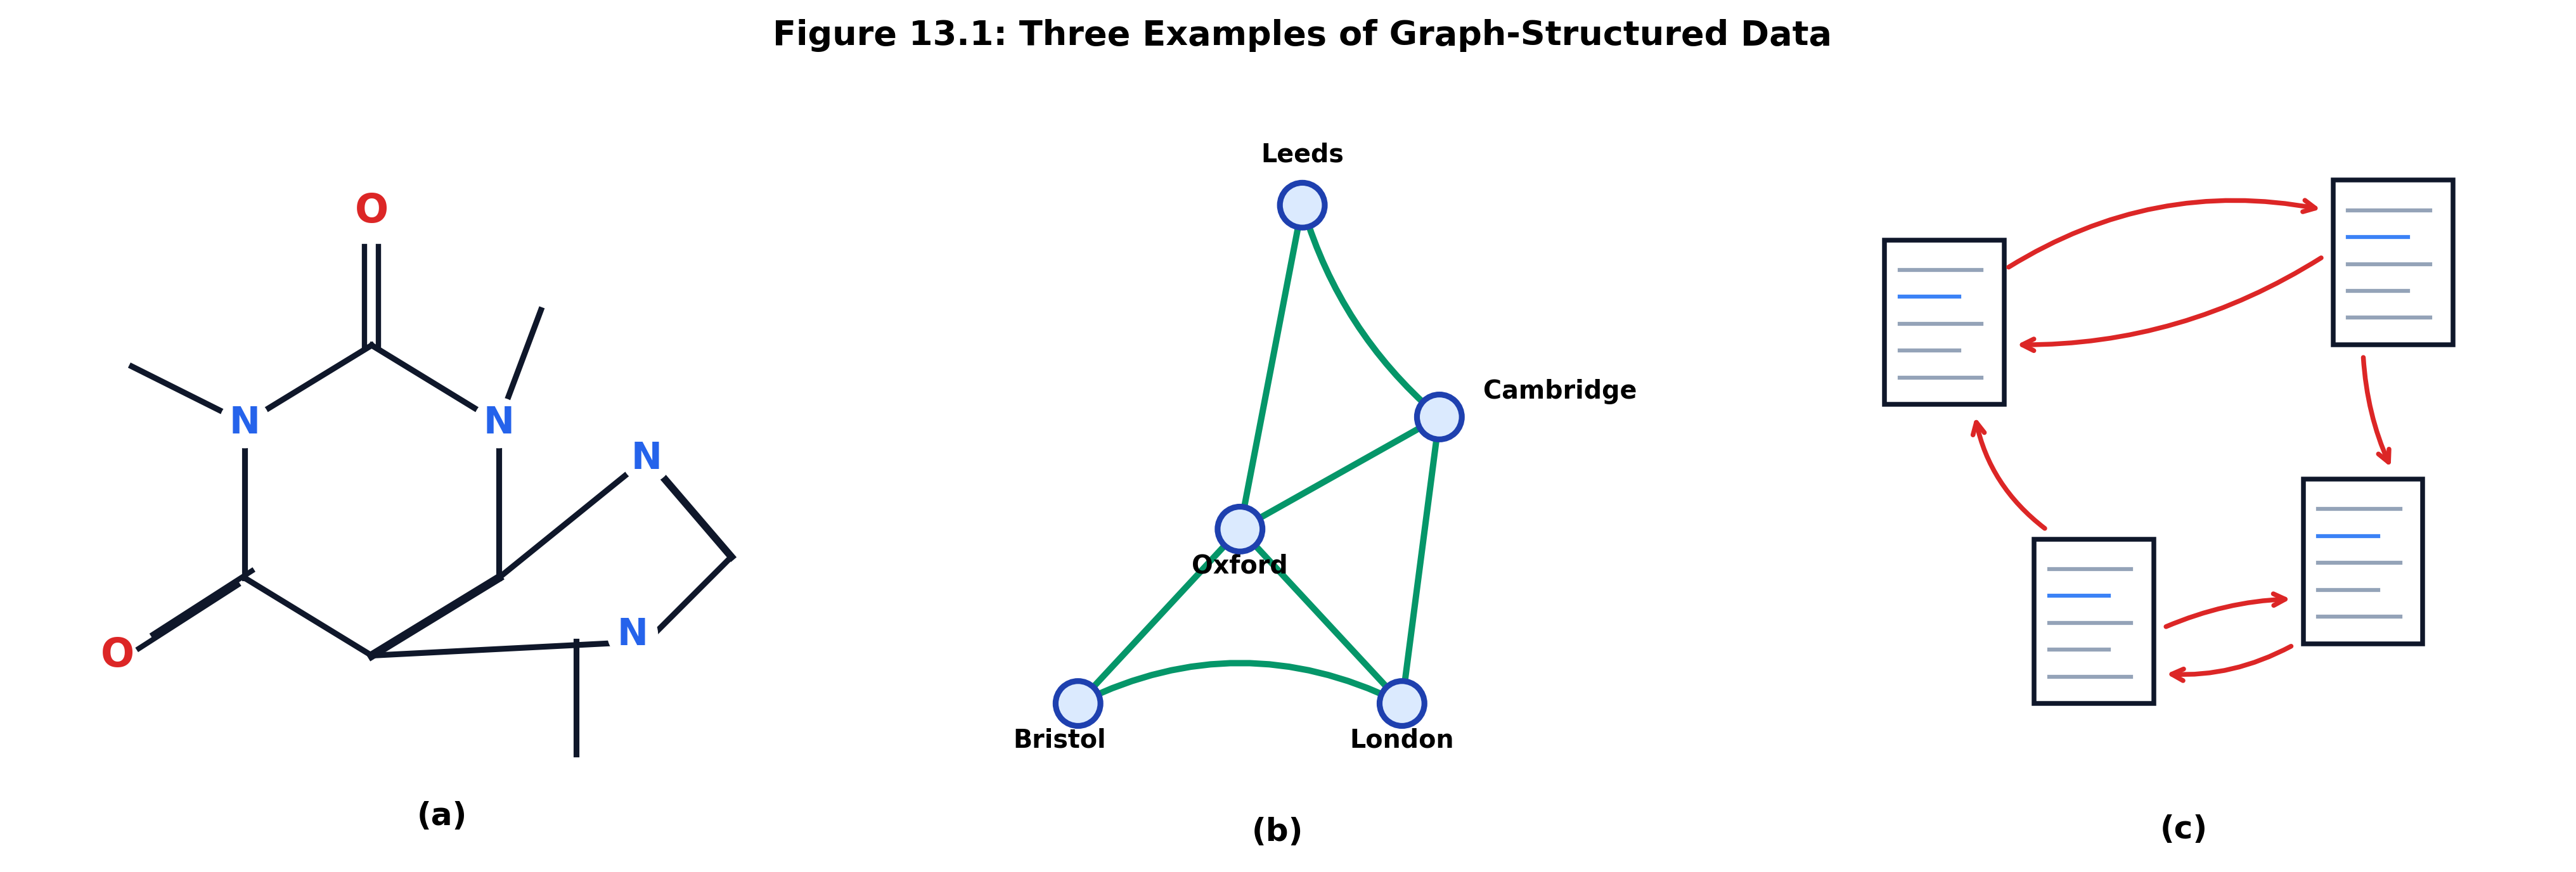

In [2]:
# Figure 13.1 グラフ構造化データの実例図の生成と表示
fig_13_1 = generate_figure_13_1()
plt.show()


## 3. 隣接行列とスペクトル行列表現 (Adjacency Matrix & Graph Laplacians, Section 13.1.2)

グラフのトポロジー構造をニューラルネットワークに入力するための最も基本となる行列表現が **隣接行列 (Adjacency Matrix)** です。

### 3.1 隣接行列と次数行列
ノードに任意の順序 $1, \dots, N$ を割り振ったとき、$N \times N$ の隣接行列 $A$ の各要素は次のように定義されます：
$$A_{nm} = \begin{cases} 1 & (v_n, v_m) \in E \\ 0 & (v_n, v_m) \notin E \end{cases}$$
無向グラフでは $(v_n, v_m) \in E \iff (v_m, v_n) \in E$ であるため、隣接行列は対称行列（$A = A^T$）となります。

ノード $n$ に接続するエッジの総数を **次数 (Degree)** $d_n$ と呼び、これを対角要素に並べた対角行列を **次数行列 (Degree Matrix)** $D$ と呼びます：
$$d_n = \sum_{m=1}^N A_{nm}, \quad D = \text{diag}(d_1, \dots, d_N)$$

### 3.2 グラフラプラシアン (Graph Laplacians)
グラフ上のスペクトル解析や拡散過程において、グラフラプラシアンは微分作用素（ラプラシアン $\nabla^2$）の離散アナログとして中心的な役割を果たします：
1. **非正規化ラプラシアン (Unnormalized Laplacian)**:
   $$L = D - A$$
   - 各行の和はゼロです: $L \mathbf{1} = (D - A)\mathbf{1} = \mathbf{d} - \mathbf{d} = \mathbf{0}$。
   - 任意のベクトル $\mathbf{f}$ に対し、二次形式は $\mathbf{f}^T L \mathbf{f} = \frac{1}{2} \sum_{n, m} A_{nm} (f_n - f_m)^2 \ge 0$ となり、半正定値行列です（全固有値 $\lambda_i \ge 0$）。
2. **対称正規化ラプラシアン (Symmetric Normalized Laplacian)**:
   $$L_{\text{sym}} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} A D^{-1/2}$$
   - 全固有値は $[0, 2]$ の区間に収まります。
3. **ランダムウォークラプラシアン (Random Walk Laplacian)**:
   $$L_{\text{rw}} = D^{-1} L = I - D^{-1} A$$
4. **自己ループ付き再正規化隣接行列 (Renormalized Adjacency)**:
   GCN (Kipf & Welling, 2017) では、ノード自身の情報保持のため単位行列を加えた $\widetilde{A} = A + I_N$、$\widetilde{D}_{nn} = \sum_m \widetilde{A}_{nm}$ を定義し、対称正規化：
   $$\widetilde{A}_{\text{norm}} = \widetilde{D}^{-1/2} \widetilde{A} \widetilde{D}^{-1/2}$$
   を用います。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/fig_13_2_adjacency_matrix.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_13_2_adjacency_matrix.png


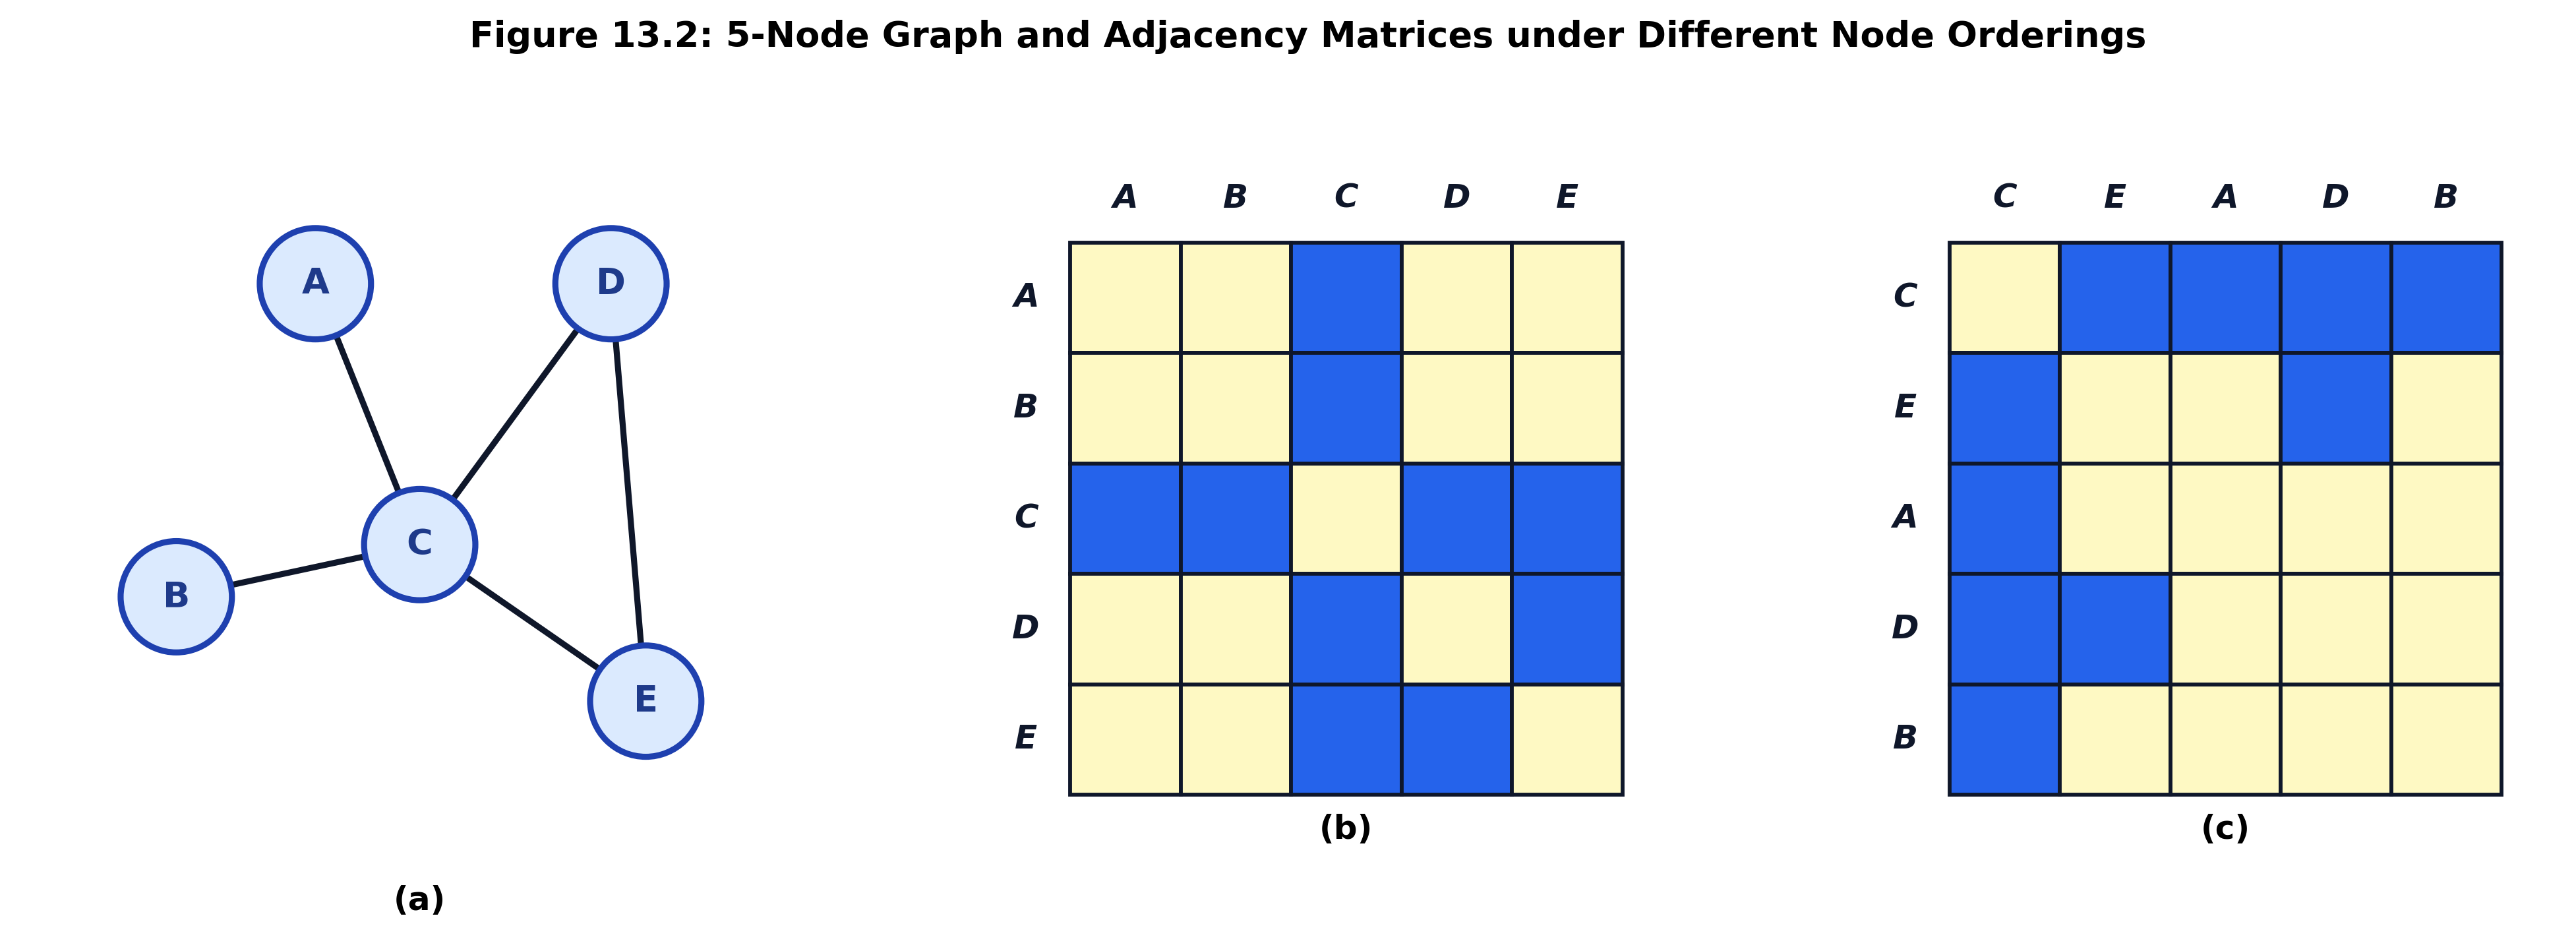

--- 図 13.2 の5ノードグラフの行列表現 ---
隣接行列 A:
 [[0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 1. 0. 1. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 1. 0.]]
次数ベクトル d: [1. 1. 4. 2. 2.]
次数行列 D:
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 4. 0. 0.]
 [0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 2.]]
グラフラプラシアン L = D - A:
 [[ 1.  0. -1.  0.  0.]
 [ 0.  1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0. -1. -1.  2.]]
L の固有値: [0. 1. 1. 3. 5.]
対称正規化ラプラシアン L_sym の固有値: [0.    0.691 1.    1.5   1.809]


In [3]:
# Figure 13.2 5ノードグラフと隣接行列の順序による変形
fig_13_2 = generate_figure_13_2()
plt.show()

# Graph クラスによる行列計算の検証
edges = [(0, 2), (1, 2), (2, 3), (2, 4), (3, 4)]
g = Graph(num_nodes=5, edges=edges, node_labels=["A", "B", "C", "D", "E"])

print("--- 図 13.2 の5ノードグラフの行列表現 ---")
print("隣接行列 A:\n", g.A)
print("次数ベクトル d:", g.degrees)
print("次数行列 D:\n", g.degree_matrix)
print("グラフラプラシアン L = D - A:\n", g.laplacian)
print("L の固有値:", np.round(np.linalg.eigvalsh(g.laplacian), 4))
print("対称正規化ラプラシアン L_sym の固有値:", np.round(np.linalg.eigvalsh(g.normalized_laplacian), 4))


## 4. 置換等変性と置換不変性 (Permutation Equivariance & Invariance, Section 13.1.3)

隣接行列を平坦化（flatten）して通常の全結合ニューラルネットワークに入力することは致命的な欠陥をもたらします。なぜなら、ノードの番号付け（順序）は完全に任意であり、ノードの並べ替え（置換）によって隣接行列の形状が激変してしまうためです（Figure 13.2）。$N$ 個のノードには $N!$ 通りの番号付けが存在するため、データ拡張でこれを学習することは計算量的に不可能です。
したがって、**ノード順序に対する対称性をネットワークの帰納バイアス (Inductive Bias) としてアーキテクチャに直接組み込む** 必要があります。

### 4.1 置換行列 (Permutation Matrix) の代数
ノードの並べ替えを数学的に記述するため、置換行列 $P \in \{0, 1\}^{N \times N}$ を導入します（式 13.1, 13.3）。
各行に 1 が1つ、各列に 1 が1つだけ存在し、他はすべて 0 です。
置換関数 $\pi(n)$ に対して：
$$P = \begin{pmatrix} \mathbf{u}_{\pi(1)}^T \\ \mathbf{u}_{\pi(2)}^T \\ \vdots \\ \mathbf{u}_{\pi(N)}^T \end{pmatrix} \tag{13.3}$$
置換行列は直交行列であり、$P^{-1} = P^T$、すなわち $P P^T = P^T P = I_N$ を満たします。

### 4.2 グラフデータの置換変換
ノードのラベルを並べ替えると：
1. **ノード特徴量行列の変換**: 行が $\pi$ に従って並べ替えられるため、左から $P$ を乗算します：
   $$\widetilde{X} = P X \tag{13.4}$$
2. **隣接行列の変換**: 行と列の双方が並べ替えられるため、行の並べ替え $P$ と列の並べ替え $P^T$ を適用します：
   $$\widetilde{A} = P A P^T \tag{13.5}$$

### 4.3 不変性 (Invariance) と等変性 (Equivariance) の数理的定義
ニューラルネットワークの関数 $f(A, X)$ において：
- **置換不変性 (Permutation Invariance, 式 13.6)**: グラフ全体の特性予測（分子水溶性など）は、ノードの番号付けをどのように変えても出力が完全に不変でなければなりません：
  $$f(P A P^T, P X) = f(A, X) \tag{13.6}$$
- **置換等変性 (Permutation Equivariance, 式 13.7)**: 各ノードの個別予測（ノード分類など）は、ノード番号の並べ替えに応じて出力ベクトルの行も全く同一の並べ替えを受けなければなりません：
  $$f(P A P^T, P X) = P f(A, X) \tag{13.7}$$

### 4.4 同変層の多段結合原理
各隠れ層 $H^{(l+1)} = \text{Layer}(A, H^{(l)})$ が置換等変性を満たしていれば、それらを何層重ねてもネットワーク全体は置換等変性を維持します：
$$H^{(l+1)}(P A P^T, P H^{(l)}) = P H^{(l+1)}(A, H^{(l)})$$
そして最後に大域プーリング（和、平均、最大値などの対称関数）を適用することで、自動的に置換不変なグラフ全体表現が得られます。これがグラフニューラルネットワーク（GNN）の普遍的設計原理です。


In [4]:
# 置換行列 P の構成と変換の検証
perm = [2, 4, 0, 3, 1]  # (A, B, C, D, E) -> (C, E, A, D, B)
P = build_permutation_matrix(perm)

print("置換行列 P (式 13.1):\n", P)
print("直交性の検証 P @ P.T == I:", np.allclose(np.matmul(P, P.T), np.eye(5)))

# ノード等変層（GCN層）の動作検証
rng = np.random.default_rng(42)
X_dummy = rng.normal(size=(5, 4))
W_dummy = rng.normal(size=(4, 4))

is_equiv, max_diff_equiv = check_node_equivariance(
    lambda a, x: simple_gcn_layer(a, x, W=W_dummy),
    g.A, X_dummy, perm
)
print(f"GCN層のノード置換等変性 (式 13.7) 充足: {is_equiv} (最大差異 = {max_diff_equiv:.2e})")

# グラフ不変層（大域プーリング層）の動作検証
is_inv, max_diff_inv = check_graph_invariance(
    lambda a, x: simple_graph_pooling(a, x, pool_type="mean"),
    g.A, X_dummy, perm
)
print(f"大域平均プーリングのグラフ置換不変性 (式 13.6) 充足: {is_inv} (最大差異 = {max_diff_inv:.2e})")


置換行列 P (式 13.1):
 [[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]]
直交性の検証 P @ P.T == I: True
GCN層のノード置換等変性 (式 13.7) 充足: True (最大差異 = 2.22e-16)
大域平均プーリングのグラフ置換不変性 (式 13.6) 充足: True (最大差異 = 2.78e-17)


## 5. まとめと次節 13.2（ニューラル・メッセージパッシング）への展開

### 本節の要点
1. **グラフ構造の普遍性**: 非ユークリッド空間のノード $V$ とエッジ $E$ からなる多様なドメインデータ（分子、路線網、Web）を統一的に表現。
2. **隣接行列とグラフラプラシアン**: 隣接行列 $A$、次数行列 $D$、非正規化ラプラシアン $L = D - A$、対称正規化ラプラシアン $L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$ の数理的性質。
3. **置換対称性の不可欠性**: ノード番号の任意性に対処するため、ノードレベルの置換等変性（式 13.7）とグラフレベルの置換不変性（式 13.6）を帰納バイアスとしてネットワークに組み込むことが必須。

---

### 次節 13.2 ニューラル・メッセージパッシング (Neural Message-Passing) への展開
次節 **13.2 Neural Message-Passing** では、画像における畳み込み演算をグラフ構造へと拡張した **メッセージパッシング・ニューラルネットワーク (MPNN)** の枠組み、メッセージ関数、集約関数（Aggregate Operator）、更新関数（Update Operator）、およびグラフ畳み込みネットワーク (GCN) の詳細な数理メカニズム（図 13.3 〜 13.5、アルゴリズム 13.1 〜 13.2）を探究します。
